In [87]:
pip install networkx


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [88]:
import numpy as np
import random
import operator
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

In [89]:
class Municipality:
    def __init__(self, name, x, y):
        self.name = name
        self.x = x
        self.y = y

    def distance(self, municipality):
        x_dis = abs(self.x - municipality.x)
        y_dis = abs(self.y - municipality.y)
        return np.sqrt((x_dis**2) + (y_dis**2))

    def __repr__(self):
        return self.name

class Fitness:
    def __init__(self, route):
        self.route = route
        self.distance = 0
        self.fitness_score = 0.0

    def route_distance(self):
        if self.distance == 0:
            path_distance = 0
            for i in range(0, len(self.route)):
                start_node = self.route[i]
                end_node = self.route[i + 1] if i + 1 < len(self.route) else self.route[0]
                path_distance += start_node.distance(end_node)
            self.distance = path_distance
        return self.distance

    def route_fitness(self):
        if self.fitness_score == 0:
            self.fitness_score = 1 / float(self.route_distance())
        return self.fitness_score

# --- MAIN ALGORITHM CLASS ---

class GeneticAlgorithmTSP:
    def __init__(
        self,
        destination_list,
        pop_size=100,
        elite_size=20,
        mutation_rate=0.01,
        generations=500):
        self.destination_list = destination_list
        self.pop_size = pop_size
        self.elite_size = elite_size
        self.mutation_rate = mutation_rate
        self.generations = generations
        self.distance_history = []
        self.best_route = None

    def _create_route(self):
        return random.sample(self.destination_list, len(self.destination_list))

    def _initial_population(self):
        return [self._create_route() for _ in range(self.pop_size)]

    def _rank_routes(self, population):
        fitness_results = {}
        for i in range(len(population)):
            fitness_results[i] = Fitness(population[i]).route_fitness()
        return sorted(fitness_results.items(), key=operator.itemgetter(1), reverse=True)

    def _selection(self, pop_ranked):
        selection_results = []
        df = pd.DataFrame(np.array(pop_ranked), columns=["Index", "Fitness"])
        df['cum_sum'] = df.Fitness.cumsum()
        df['cum_perc'] = 100 * df.cum_sum / df.Fitness.sum()
        
        for i in range(self.elite_size):
            selection_results.append(pop_ranked[i][0])
        
        for i in range(len(pop_ranked) - self.elite_size):
            pick = 100 * random.random()
            for j in range(len(pop_ranked)):
                if pick <= df.iat[j, 3]:
                    selection_results.append(pop_ranked[j][0])
                    break
        return selection_results

    def _breed(self, parent1, parent2):
        gene_a = int(random.random() * len(parent1))
        gene_b = int(random.random() * len(parent1))
        start, end = min(gene_a, gene_b), max(gene_a, gene_b)
        
        child_p1 = [parent1[i] for i in range(start, end)]
        child_p2 = [item for item in parent2 if item not in child_p1]
        return child_p1 + child_p2

    def _mutate(self, individual):
        for i in range(len(individual)):
            if random.random() < self.mutation_rate:
                j = int(random.random() * len(individual))
                individual[i], individual[j] = individual[j], individual[i]
        return individual

    def run(self):
        population = self._initial_population()
        initial_dist = 1 / self._rank_routes(population)[0][1]
        print(f"Distancia inicial: {initial_dist:.4f}")
        print("Ejecutando evolución...")

        for g in range(self.generations):
            pop_ranked = self._rank_routes(population)
            self.distance_history.append(1 / pop_ranked[0][1])
            
            selection_indices = self._selection(pop_ranked)
            mating_pool = [population[i] for i in selection_indices]
            
            # Elitismo y Reproducción
            next_gen = mating_pool[:self.elite_size]
            for i in range(len(mating_pool) - self.elite_size):
                child = self._breed(mating_pool[i], mating_pool[len(mating_pool)-i-1])
                next_gen.append(child)
            
            population = [self._mutate(ind) for ind in next_gen]

        # Obtener resultados finales
        pop_ranked = self._rank_routes(population)
        self.best_route = population[pop_ranked[0][0]]
        final_dist = 1 / pop_ranked[0][1]

        print("-" * 60)
        print(f"Distancia Final: {final_dist:.4f}")
        print("Mejor Ruta Encontrada:")
        route_str = " -> ".join([m.name for m in self.best_route])
        print(f"{route_str} -> {self.best_route[0].name}")
        print("-" * 60)
        
        return self.best_route

    def plot_network_graph(self):
            G = nx.Graph()
            
            # Agregar nodos
            for m in self.destination_list:
                G.add_node(m.name)
                
            # Agregar aristas con pesos (todas las combinaciones)
            for i in range(len(self.destination_list)):
                for j in range(i + 1, len(self.destination_list)):
                    m1, m2 = self.destination_list[i], self.destination_list[j]
                    dist = m1.distance(m2)
                    G.add_edge(m1.name, m2.name, weight=round(dist, 2))

            # Definir la ruta óptima como una lista de aristas
            optimal_edges = []
            for i in range(len(self.best_route)):
                u = self.best_route[i].name
                v = self.best_route[(i + 1) % len(self.best_route)].name
                optimal_edges.append((u, v))

            # Visualización
            plt.figure(figsize=(12, 8))
            pos = nx.circular_layout(G) # Layout circular para mayor claridad
            
            # Dibujar todos los nodos y aristas tenues
            nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue')
            nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif')
            nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=1, alpha=0.1, edge_color='gray')
            
            # Resaltar la ruta óptima
            nx.draw_networkx_edges(G, pos, edgelist=optimal_edges, width=3, edge_color='red', label='Ruta Óptima')
            
            # Dibujar pesos de las aristas (solo de la ruta óptima para no saturar)
            edge_labels = {(u, v): G[u][v]['weight'] for u, v in optimal_edges}
            nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

            plt.title("Representación de Red: Grafo Completo y Ruta Óptima")
            plt.legend(loc='upper left')
            plt.axis('off')
            plt.show()

    def plot_learning_curve(self):
        plt.figure(figsize=(10, 6))
        plt.plot(self.distance_history, color='#2c3e50', linewidth=1.5)
        plt.title('Curva de Aprendizaje - Algoritmo Genético (TSP)', fontsize=14)
        plt.xlabel('Generación', fontsize=12)
        plt.ylabel('Distancia Total de la Ruta', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

In [90]:
# Carga de datos desde CSV
df = pd.read_csv('../data/monterrey_municipalities.csv')

In [99]:
def plot_complete_network(df):
    """
    Genera un grafo completo con pesos (distancias) a partir del dataframe de maravillas.
    """
    # 1. Preprocesamiento de datos
    df_clean = df.copy()
    df_clean['Latitud'] = df_clean['Latitud'].apply(lambda x: float(str(x).replace('.', '')))
    df_clean['Longitud'] = df_clean['Longitud'].apply(lambda x: float(str(x).replace('.', '')))
    
    G = nx.Graph()
    
    # 2. Añadir nodos y calcular todas las aristas (Grafo Completo)
    nodes = df_clean['Maravilla'].tolist()
    coords = df_clean.set_index('Maravilla')[['Latitud', 'Longitud']].to_dict('index')
    
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            m1, m2 = nodes[i], nodes[j]
            # Cálculo de distancia Euclidiana
            dist = np.sqrt(
                (coords[m1]['Latitud'] - coords[m2]['Latitud'])**2 + 
                (coords[m1]['Longitud'] - coords[m2]['Longitud'])**2
            )
            G.add_edge(m1, m2, weight=round(dist, 2))

    # 3. Configuración del Layout y Dibujo
    plt.figure(figsize=(14, 10))
    # Usamos shell_layout para que los nombres no se encimen y se vea la red completa
    pos = nx.shell_layout(G)
    
    # Dibujar Nodos
    nx.draw_networkx_nodes(G, pos, node_size=1200, node_color='skyblue', edgecolors='navy')
    
    # Dibujar Etiquetas de Nodos
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', font_family='sans-serif')
    
    # Dibujar Aristas (con transparencia para notar la red)
    nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.4, edge_color='gray')
    
    # Dibujar Pesos (Distancias)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, label_pos=0.3)

    plt.title("Grafo Completo de los municipios de Monterrey (Red de Distancias)", fontsize=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

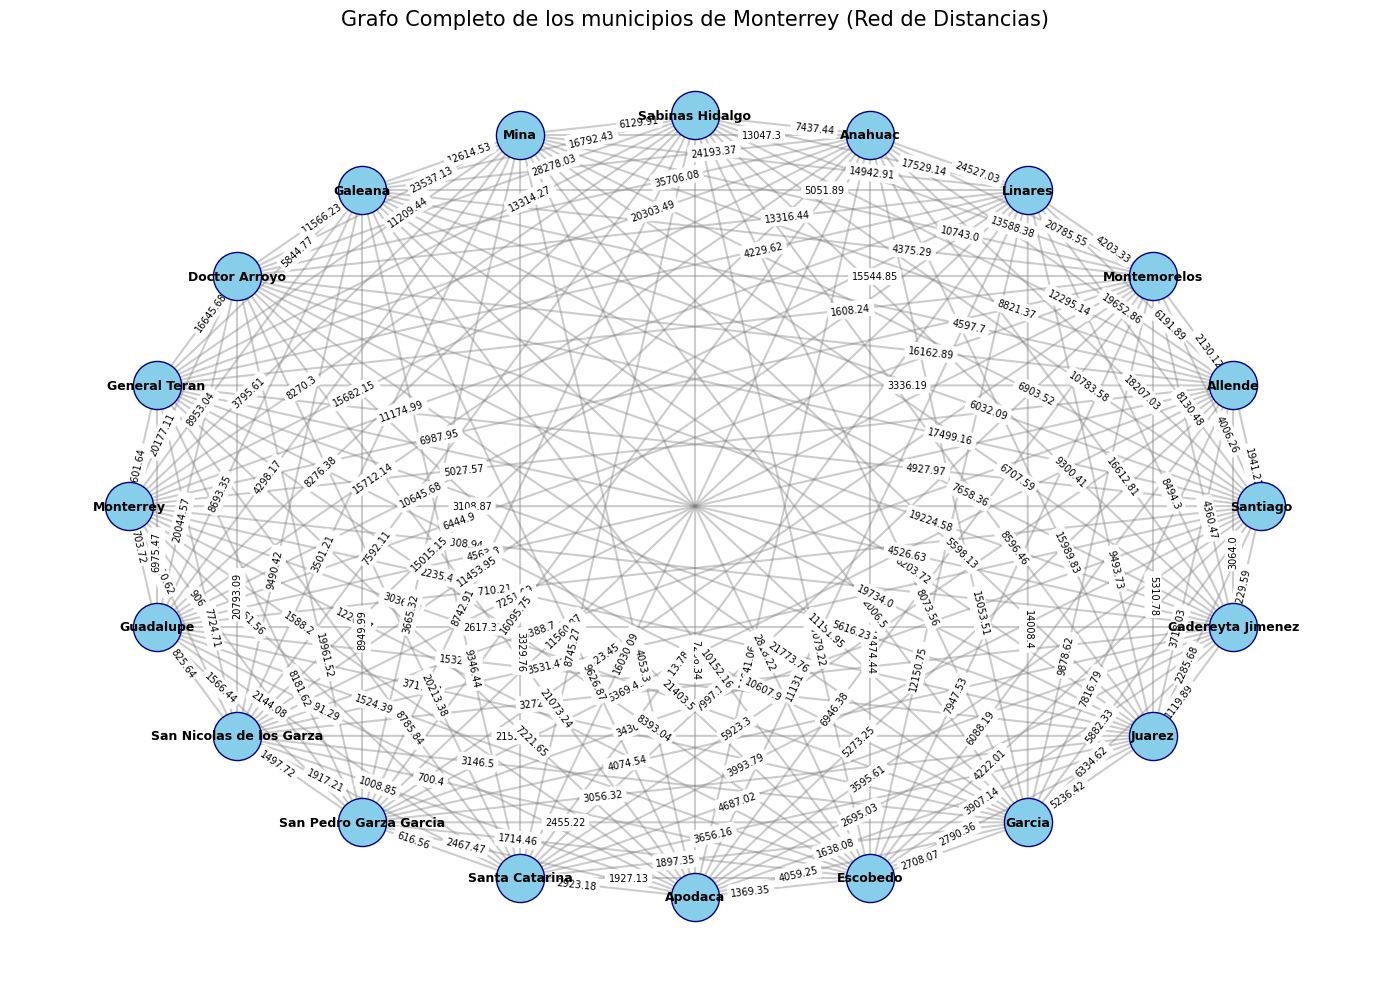

In [100]:
plot_complete_network(df)

In [101]:
destinations = []
for _, row in df.iterrows():
    # Ajuste de coordenadas (eliminando puntos de miles)
    lat = float(str(row['Latitud']).replace('.', ''))
    lon = float(str(row['Longitud']).replace('.', ''))
    destinations.append(Municipality(row['Maravilla'], lat, lon))



In [102]:
destinations

[Monterrey,
 Guadalupe,
 San Nicolas de los Garza,
 San Pedro Garza Garcia,
 Santa Catarina,
 Apodaca,
 Escobedo,
 Garcia,
 Juarez,
 Cadereyta Jimenez,
 Santiago,
 Allende,
 Montemorelos,
 Linares,
 Anahuac,
 Sabinas Hidalgo,
 Mina,
 Galeana,
 Doctor Arroyo,
 General Teran]

In [110]:
# Instancia y ejecución de la clase
ga = GeneticAlgorithmTSP(
    destinations,
    pop_size=40,
    elite_size=20,
    generations=500)

In [111]:
best_path = ga.run()

Distancia inicial: 140444.7927
Ejecutando evolución...
------------------------------------------------------------
Distancia Final: 84204.0669
Mejor Ruta Encontrada:
Juarez -> Guadalupe -> San Nicolas de los Garza -> Escobedo -> Monterrey -> San Pedro Garza Garcia -> Santa Catarina -> Garcia -> Mina -> Anahuac -> Sabinas Hidalgo -> Apodaca -> Santiago -> Allende -> Montemorelos -> Galeana -> Doctor Arroyo -> Linares -> General Teran -> Cadereyta Jimenez -> Juarez
------------------------------------------------------------


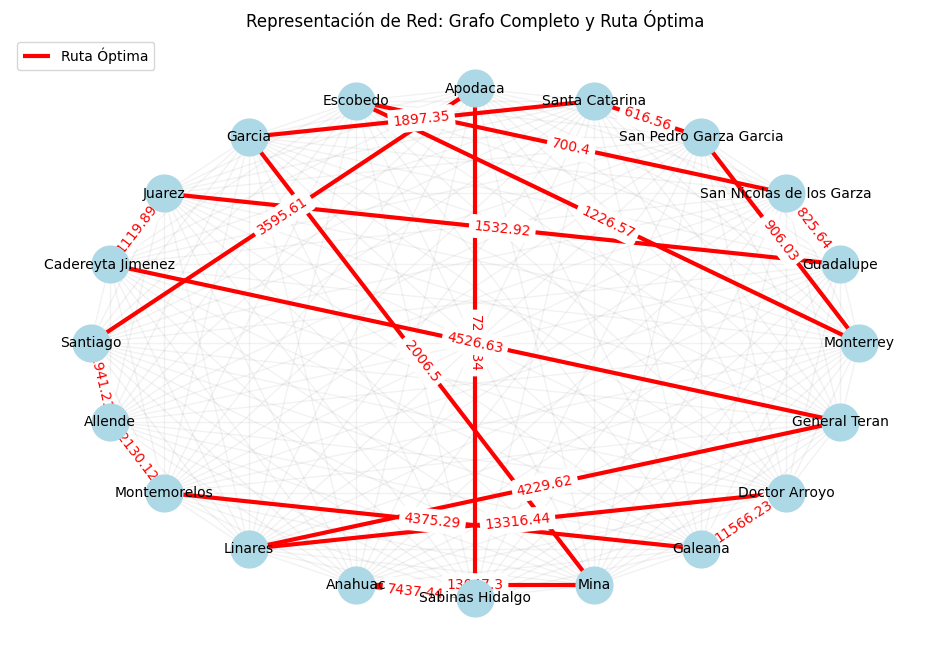

In [112]:
ga.plot_network_graph()

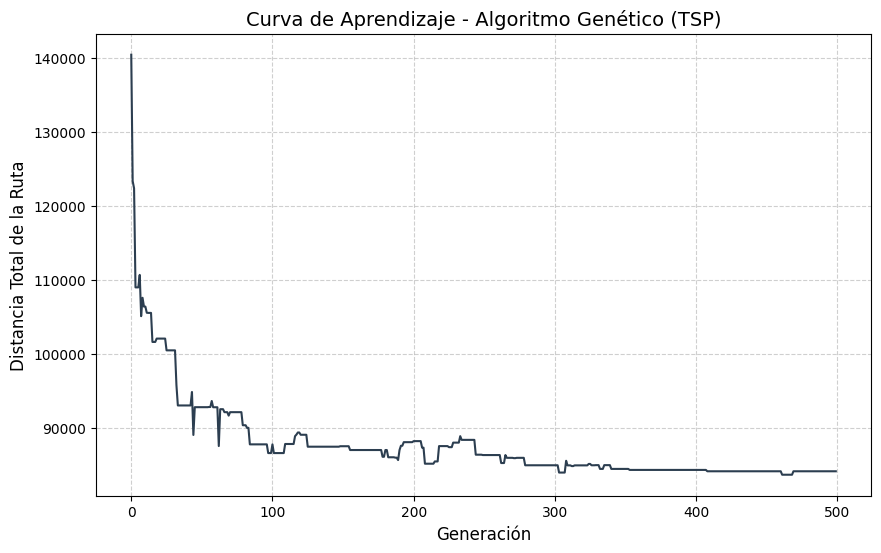

In [113]:
ga.plot_learning_curve()